In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import MDAnalysis

import tqdm

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/TPRParser.py:161: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [2]:
prefix_path='../../../LC3_MAIN_TRAJECTORIES/PROTEIN_ONLY_FITTED'

#PRE
pre_LC3B_S1=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM1_dt1000.pdb'%prefix_path)
pre_LC3B_S2=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM2_dt1000.pdb'%prefix_path)
pre_LC3B_S3=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM3_dt1000.pdb'%prefix_path)


#UNB
u_unbound_ER_S1 = MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM1_dt1000.pdb"%prefix_path)
u_unbound_ER_S2 =MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM2_dt1000.pdb"%prefix_path)
u_unbound_ER_S3=MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM3_dt1000.pdb"%prefix_path)

#BND
u_bound_ER_S1 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM1_dt1000.pdb"%prefix_path)
u_bound_ER_S2 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM2_dt1000.pdb"%prefix_path)
u_bound_ER_S3 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM3_dt1000.pdb"%prefix_path)





In [3]:
def min_dist(Traj,pairs):
    distt_ls=[]
    total_frames=len(Traj.trajectory)

    for t in Traj.trajectory:
        #selecting all the heavy atoms 
        sel1=Traj.select_atoms('resid %d and not type H'%pairs[0])
        sel2=Traj.select_atoms('resid %d and not type H'%pairs[1])
        dist_ls=[]
        for i in sel1.atoms:
            for j in sel2.atoms:

                pos_1=np.array(i.position)  
                pos_2=np.array(j.position)

                dist=np.linalg.norm(pos_1 - pos_2)
                dist_ls.append(dist)
        distt_ls.append(min(dist_ls))
    return(distt_ls)
    

In [4]:
from numpy.linalg import norm

def angle_measurement(RES_A,RES_B,RES_C,traj):
    angles=[]
    for ts in traj.trajectory[0:len(traj.trajectory)]:
        A = traj.select_atoms("resid %d and name CA"%RES_A).positions[0]
        B = traj.select_atoms("resid %d and name CA"%RES_B).positions[0]
        C = traj.select_atoms("resid %d and name CA"%RES_C).positions[0]

        BA = A - B
        BC = C - B
        theta = np.arccos(np.dot(BA, BC)/(norm(BA)*norm(BC)))
        theta_deg=np.rad2deg(theta)
        angles.append(theta_deg)
    return(angles)




In [5]:
req_pairs=[(64,89)]
lc3b_unb_mindist_1=min_dist(u_unbound_ER_S1,req_pairs[0])+min_dist(u_unbound_ER_S2,req_pairs[0])+min_dist(u_unbound_ER_S3,req_pairs[0])
lc3b_bnd_mindist_1=min_dist(u_bound_ER_S1,req_pairs[0])+min_dist(u_bound_ER_S2,req_pairs[0])+min_dist(u_bound_ER_S3,req_pairs[0])
pre_mindist_1=min_dist(pre_LC3B_S1,req_pairs[0])+min_dist(pre_LC3B_S2,req_pairs[0])+min_dist(pre_LC3B_S3,req_pairs[0])


In [6]:
pre_angle=angle_measurement(80,85,89,pre_LC3B_S1)+angle_measurement(80,85,89,pre_LC3B_S2)+\
angle_measurement(80,85,89,pre_LC3B_S3)

unb_angle=angle_measurement(80,85,89, u_unbound_ER_S1)+angle_measurement(80,85,89, u_unbound_ER_S2)+\
angle_measurement(80,85,89, u_unbound_ER_S3)

bnd_angle=angle_measurement(80,85,89,u_bound_ER_S1)+angle_measurement(80,85,89,u_bound_ER_S2)+\
angle_measurement(80,85,89,u_bound_ER_S3)


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


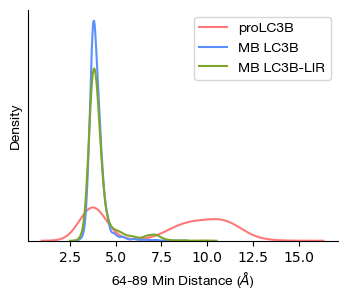

In [7]:
font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(figsize=(4, 3))

sns.kdeplot(pre_mindist_1,
           color='#FF7878',label='proLC3B',ax=ax)
sns.kdeplot(lc3b_unb_mindist_1,
           color='#5A91FF',label='MB LC3B',ax=ax)
sns.kdeplot(lc3b_bnd_mindist_1,
           color='#7DA629',label='MB LC3B-LIR',ax=ax)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_title('Mean D', fontdict=font)
ax.set_xlabel('64-89 Min Distance ($\AA$)', fontdict=font)
ax.set_ylabel('Density', fontdict=font)

ax.set_yticks([],[])
ax.legend(prop=rs)


#ax.set_title('Distance I64-V89',fontdict=font)

plt.savefig('../../plots/geometric_analysis/min_distance_distribution_64_89.png',
                   dpi=450,
                    bbox_inches='tight',transparent=True)

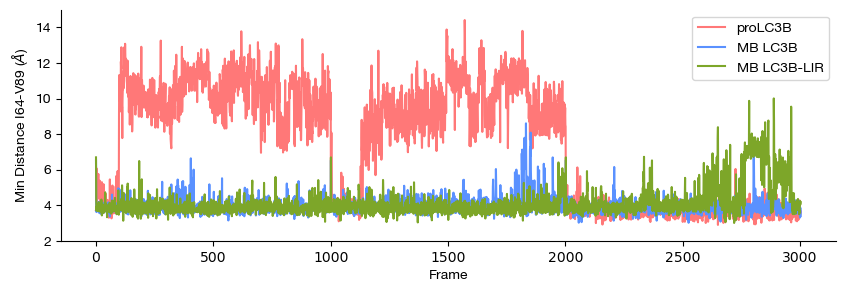

In [8]:
font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 10
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(pre_mindist_1,
           color='#FF7878',label='proLC3B')
ax.plot(lc3b_unb_mindist_1,
           color='#5A91FF',label='MB LC3B')
ax.plot(lc3b_bnd_mindist_1,
           color='#7DA629',label='MB LC3B-LIR')




ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_title('Mean D', fontdict=font)
# ax.set_ylabel('Distance ($\AA$)', fontdict=font)

ax.set_yticks([2,4,6,8,10,12,14],[2,4,6,8,10,12,14],
             fontdict=font)
ax.set_ylim(2,15)
ax.legend(prop=rs)


ax.set_ylabel('Min Distance I64-V89 ($\AA$)', fontdict=font)
ax.set_xlabel('Frame', fontdict=font)

plt.savefig('../../plots/geometric_analysis/min_distance_time_evo_64_89.png',
                   dpi=450,
                    bbox_inches='tight',transparent=True)

In [9]:
# computing density
def manhattan_dist_1d(p1,p2):
    manhattan_dist=abs(p1-p2)
    return(manhattan_dist)

def chebyshev_dist(p1,p2):
    return(max(np.abs(p1[0]-p2[0]),np.abs(p1[1]-p2[1])))

def neigh_ret(k_val, df_n, col_i,col_j):
    k3_all=k_val


    xy=[]
    for i,j in zip(df_n[col_i],
                df_n[col_j]):
        xy.append([i/max(df_n[col_i]),j/max(df_n[col_j])])

    neigh=[]
    for i in xy:
        counter=0
        ref_point=i
        radius=[]
        for j in xy:
            if j!=ref_point:
                dist_measure=chebyshev_dist(ref_point,j)
                if dist_measure<k3_all:
                    counter=counter+1

        neigh.append(counter) 
    
    return neigh


In [10]:
pre_dist_angle=pd.DataFrame()
pre_dist_angle['angle_80_85_89']=pre_angle
pre_dist_angle['dist_64_89']=pre_mindist_1

unb_dist_angle=pd.DataFrame()
unb_dist_angle['angle_80_85_89']=unb_angle
unb_dist_angle['dist_64_89']=lc3b_unb_mindist_1

bnd_dist_angle=pd.DataFrame()
bnd_dist_angle['angle_80_85_89']=bnd_angle
bnd_dist_angle['dist_64_89']=lc3b_bnd_mindist_1


In [11]:
pre_dist_angle['neigh']=neigh_ret(0.05, pre_dist_angle,'dist_64_89','angle_80_85_89')
pre_dist_angle['Sims']=['S1-%d'%i for i in range(1,1002)]+['S2-%d'%i for i in range(1,1002)]+['S3-%d'%i for i in range(1,1002)]

pre_dist_angle=pre_dist_angle.sort_values(by='neigh',
                                  ascending=False)

unb_dist_angle['neigh']=neigh_ret(0.05, unb_dist_angle,'dist_64_89','angle_80_85_89')
unb_dist_angle['Sims']=['S1-%d'%i for i in range(1,1002)]+['S2-%d'%i for i in range(1,1002)]+['S3-%d'%i for i in range(1,1002)]

unb_dist_angle=unb_dist_angle.sort_values(by='neigh',
                                  ascending=False)

bnd_dist_angle['neigh']=neigh_ret(0.05, bnd_dist_angle,'dist_64_89','angle_80_85_89')
bnd_dist_angle['Sims']=['S1-%d'%i for i in range(1,1002)]+['S2-%d'%i for i in range(1,1002)]+['S3-%d'%i for i in range(1,1002)]

bnd_dist_angle=bnd_dist_angle.sort_values(by='neigh',
                                  ascending=False)

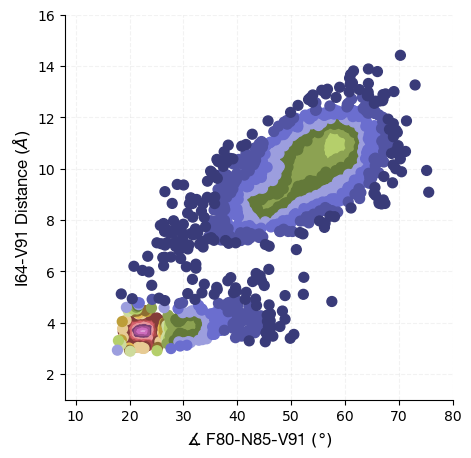

In [12]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':14
   }


fig, ax = plt.subplots(figsize=(5, 5))

# sns.kdeplot(pre_dist_angle,
#              x='angle_80_85_89',
#              y='dist_64_89',cmap='tab20b')
ax.scatter(pre_dist_angle['angle_80_85_89'],
            pre_dist_angle['dist_64_89'],
            c=pre_dist_angle['neigh'],
           cmap='tab20b',s=50)

# ax.scatter([3.794273],[7.443357], marker='*',s=60)

# ax.set_ylim(-3,250)
# ax.set_xlim(-3,200)

ax.set_ylim(1,16)
ax.set_xlim(8,80)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



# ax.set_title('CS LC3B', fontdict=font)
ax.set_ylabel('I64-V91 Distance $(\AA)$', fontdict=font)
ax.set_xlabel('$\measuredangle$ F80-N85-V91 $(\degree)$', fontdict=font)

plt.savefig('../../plots/geometric_analysis/pre_64_91dist_vs_80_85_89angle.png', 
                   dpi=650, bbox_inches='tight',
           transparent=True)

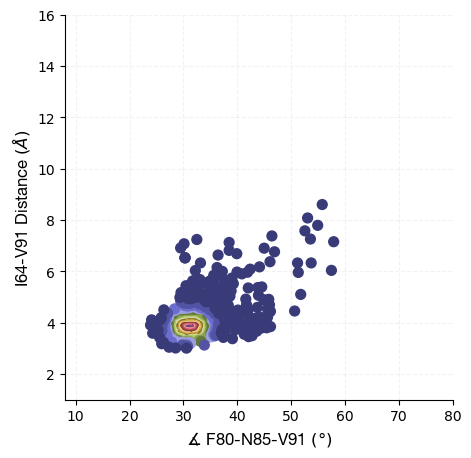

In [13]:


fig, ax = plt.subplots(figsize=(5, 5))


ax.scatter(unb_dist_angle['angle_80_85_89'],
            unb_dist_angle['dist_64_89'],
            c=unb_dist_angle['neigh'],
           cmap='tab20b',s=50)

# ax.scatter([3.794273],[7.443357], marker='*',s=60)

# ax.set_ylim(-3,250)
# ax.set_xlim(-3,200)

ax.set_ylim(1,16)
ax.set_xlim(8,80)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



# ax.set_title('CS LC3B', fontdict=font)
ax.set_ylabel('I64-V91 Distance $(\AA)$', fontdict=font)
ax.set_xlabel('$\measuredangle$ F80-N85-V91 $(\degree)$', fontdict=font)

plt.savefig('../../plots/geometric_analysis/unb_64_91dist_vs_80_85_89angle.png', 
                   dpi=650, bbox_inches='tight',
           transparent=True)

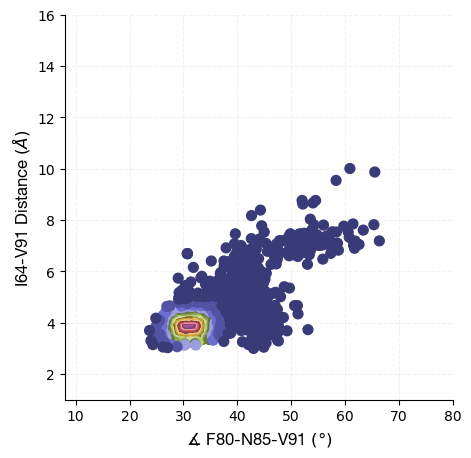

In [14]:


fig, ax = plt.subplots(figsize=(5, 5))


ax.scatter(bnd_dist_angle['angle_80_85_89'],
            bnd_dist_angle['dist_64_89'],
            c=bnd_dist_angle['neigh'],
           cmap='tab20b',s=50)

# ax.scatter([3.794273],[7.443357], marker='*',s=60)

# ax.set_ylim(-3,250)
# ax.set_xlim(-3,200)

ax.set_ylim(1,16)
ax.set_xlim(8,80)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



# ax.set_title('CS LC3B', fontdict=font)
ax.set_ylabel('I64-V91 Distance $(\AA)$', fontdict=font)
ax.set_xlabel('$\measuredangle$ F80-N85-V91 $(\degree)$', fontdict=font)

plt.savefig('../../plots/geometric_analysis/bnd_64_91dist_vs_80_85_89angle.png', 
                   dpi=650, bbox_inches='tight',
           transparent=True)

In [15]:
# TRIAD AREA 

def triangle_area (r1,r2,r3, traj): # compluted the area of triangle formed by the 3D points
    area_ls=[]
    for ts in tqdm.tqdm(traj.trajectory):
        
        sel_p1=traj.select_atoms('resid %d-%d'%(r1[0],r1[1])).center_of_geometry()
        sel_p2=traj.select_atoms('resid %d-%d'%(r2[0],r2[1])).center_of_geometry()
        sel_p3=traj.select_atoms('resid %d-%d'%(r3[0],r3[1])).center_of_geometry()
        
        #AB
        p1_p2=np.array([sel_p2[0]-sel_p1[0],sel_p2[1]-sel_p1[1],sel_p2[2]-sel_p1[2]])
        
        #AC
        p1_p3=np.array([sel_p3[0]-sel_p1[0], sel_p3[1]-sel_p1[1], sel_p3[2]-sel_p1[2]])
        
        cross_prod=np.cross(p1_p2, p1_p3)
        mag_=(cross_prod[0]**2)+(cross_prod[1]**2)+(cross_prod[2]**2)
        mag_=np.sqrt(mag_)
        area=(1/2)*mag_
        
        area_ls.append(area)
        
    return area_ls

In [16]:
PRE_S1_triangle_area=triangle_area((85,91), (60,70),(71,79), pre_LC3B_S1)
PRE_S2_triangle_area=triangle_area((85,91), (60,70),(71,79), pre_LC3B_S2)
PRE_S3_triangle_area=triangle_area((85,91), (60,70),(71,79), pre_LC3B_S3)

UNB_S1_triangle_area=triangle_area((85,91), (60,70),(71,79), u_unbound_ER_S1)
UNB_S2_triangle_area=triangle_area((85,91), (60,70),(71,79), u_unbound_ER_S2)
UNB_S3_triangle_area=triangle_area((85,91), (60,70),(71,79), u_unbound_ER_S3)
unb_triangle_area=UNB_S1_triangle_area+UNB_S2_triangle_area+UNB_S3_triangle_area

BND_S1_triangle_area=triangle_area((85,91), (60,70),(71,79), u_bound_ER_S1)
BND_S2_triangle_area=triangle_area((85,91), (60,70),(71,79), u_bound_ER_S2)
BND_S3_triangle_area=triangle_area((85,91), (60,70),(71,79), u_bound_ER_S3)
bnd_triangle_area=BND_S1_triangle_area+BND_S2_triangle_area+BND_S3_triangle_area


100%|████████████████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:01<00:00, 503.92it/s]


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


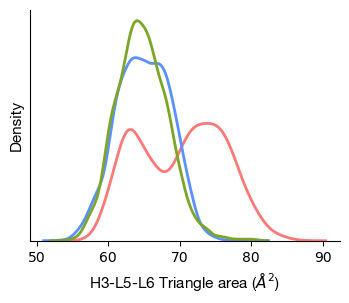

In [17]:
font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 11
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(figsize=(4, 3))




sns.kdeplot(PRE_S1_triangle_area+\
           PRE_S2_triangle_area+\
           PRE_S3_triangle_area, color='#FF7878', lw=2)
sns.kdeplot(unb_triangle_area,color='#5A91FF',lw=2)
sns.kdeplot(bnd_triangle_area,color='#7DA629',lw=2)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_yticks([],[])
# ax.set_title('Mean D', fontdict=font)
ax.set_xlabel('H3-L5-L6 Triangle area ($\\AA^2$)', fontdict=font)
ax.set_ylabel('Density', fontdict=font)

plt.savefig('../../plots/geometric_analysis/triad_area.png', dpi=650,
           bbox_inches='tight',transparent=True)
plt.show()

In [18]:
triangle_area_df=pd.DataFrame()
triangle_area_df['PRE']=PRE_S1_triangle_area+PRE_S2_triangle_area+PRE_S3_triangle_area
triangle_area_df['UNB']=unb_triangle_area
triangle_area_df['BND']=bnd_triangle_area
#triangle_area_df.to_csv('TRIANGLE_AREA_H3_L5_L6.csv')

In [19]:
pre_dist_angle_triad_area=pd.DataFrame()
pre_dist_angle_triad_area['Triangle area']=triangle_area_df['PRE']
pre_dist_angle_triad_area['angle_80_85_89']=pre_angle
pre_dist_angle_triad_area['dist_64_89']=pre_mindist_1

unb_dist_angle_triad_area=pd.DataFrame()
unb_dist_angle_triad_area['Triangle area']=triangle_area_df['UNB']
unb_dist_angle_triad_area['angle_80_85_89']=unb_angle
unb_dist_angle_triad_area['dist_64_89']=lc3b_unb_mindist_1

bnd_dist_angle_triad_area=pd.DataFrame()
bnd_dist_angle_triad_area['Triangle area']=triangle_area_df['BND']
bnd_dist_angle_triad_area['angle_80_85_89']=bnd_angle
bnd_dist_angle_triad_area['dist_64_89']=lc3b_bnd_mindist_1

In [20]:
pre_dist_angle_triad_area=pre_dist_angle_triad_area.sort_values(by='Triangle area',
                       ascending=False)
unb_dist_angle_triad_area=unb_dist_angle_triad_area.sort_values(by='Triangle area',
                       ascending=False)
bnd_dist_angle_triad_area=bnd_dist_angle_triad_area.sort_values(by='Triangle area',
                       ascending=False)

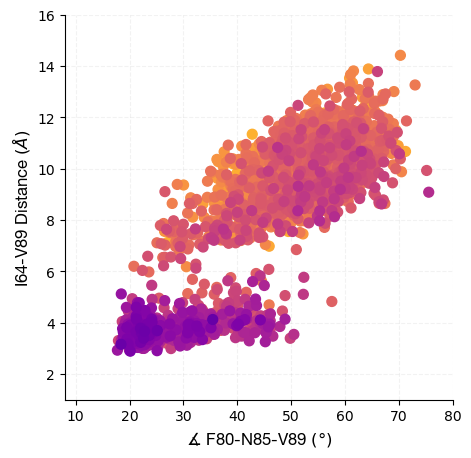

In [21]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':14
   }


fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(pre_dist_angle_triad_area['angle_80_85_89'],
            pre_dist_angle_triad_area['dist_64_89'],
            c=pre_dist_angle_triad_area['Triangle area'],
           cmap='plasma',s=50, vmin=50, vmax=87)

ax.set_ylim(1,16)
ax.set_xlim(8,80)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_ylabel('I64-V89 Distance $(\AA)$', fontdict=font)
ax.set_xlabel('$\measuredangle$ F80-N85-V89 $(\degree)$', fontdict=font)

plt.savefig('../../plots/geometric_analysis/triad_area_mapped_pre_64_89_vs_dist_80_85_89angle', 
                   dpi=650, bbox_inches='tight',
           transparent=True)

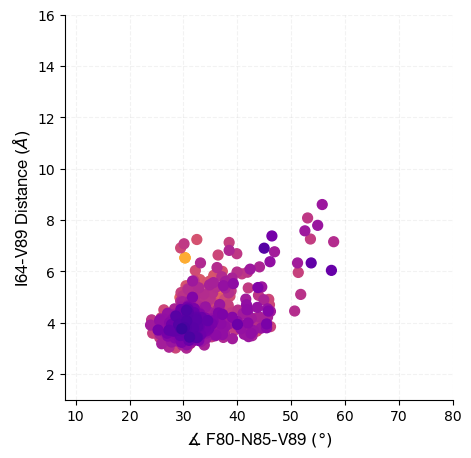

In [22]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':14
   }


fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(unb_dist_angle_triad_area['angle_80_85_89'],
            unb_dist_angle_triad_area['dist_64_89'],
            c=unb_dist_angle_triad_area['Triangle area'],
           cmap='plasma',s=50, vmin=50, vmax=87)

ax.set_ylim(1,16)
ax.set_xlim(8,80)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('I64-V89 Distance $(\AA)$', fontdict=font)
ax.set_xlabel('$\measuredangle$ F80-N85-V89 $(\degree)$', fontdict=font)

plt.savefig('../../plots/geometric_analysis/triad_area_mapped_unb_64_89_vs_dist_80_85_89angle', 
                   dpi=650, bbox_inches='tight',
           transparent=True)

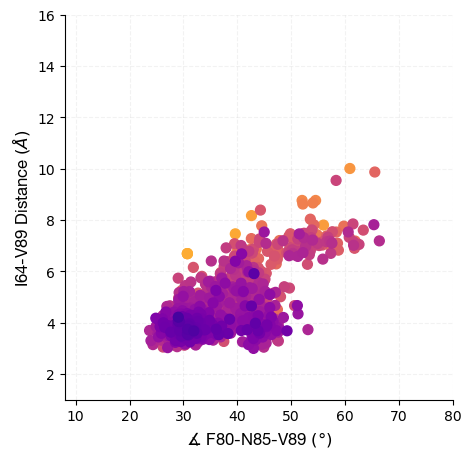

In [23]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':14
   }


fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(bnd_dist_angle_triad_area['angle_80_85_89'],
            bnd_dist_angle_triad_area['dist_64_89'],
            c=bnd_dist_angle_triad_area['Triangle area'],
           cmap='plasma',s=50, vmin=50, vmax=87)

ax.set_ylim(1,16)
ax.set_xlim(8,80)


ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('I64-V89 Distance $(\AA)$', fontdict=font)
ax.set_xlabel('$\measuredangle$ F80-N85-V89 $(\degree)$', fontdict=font)

plt.savefig('../../plots/geometric_analysis/triad_area_mapped_bnd_64_89_vs_dist_80_85_89angle', 
                   dpi=650, bbox_inches='tight',
           transparent=True)

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_36252/3906376470.py:23: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)


[Text(1, 50.0, '50.0'), Text(1, 68.5, '68.5'), Text(1, 87.0, '87.0')]

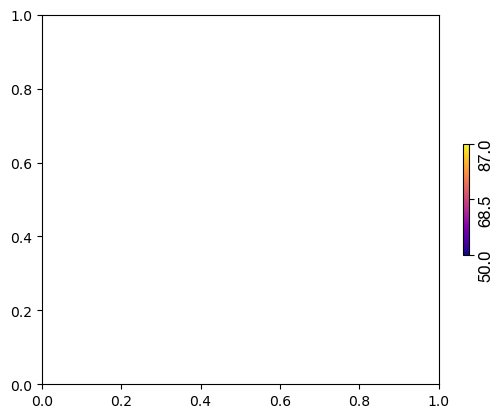

In [24]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }


import matplotlib.cm as cm
import matplotlib.colors as colors
mini=50
maxi=87
norm = colors.Normalize(vmin=mini, vmax=maxi)

cmp='plasma'

f2rgb2 = cm.ScalarMappable(norm=norm, cmap=cmp)
f2rgb2.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)
cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), rotation=90,fontdict=font)


# plt.savefig('triad_area_cbar.png',
#                    dpi=450,transparent=True,
#                    bbox_inches='tight')